# Actividad 1: Modelos de Regresión Lineal Simple y Múltiple - André Guillermo Carvajal Flores  


In [24]:
# 1. Importación de bibliotecas científicas y de visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (8, 5), 'font.size': 10})
pd.options.display.max_columns = 50
pd.options.display.float_format = '{:.4f}'.format

print("Bibliotecas cargadas exitosamente.")


Bibliotecas cargadas exitosamente.


In [25]:
# 2. Carga y verificación del dataset depurado de Boston
df = pd.read_csv('Datos_limpios_Boston.csv')
print(f"Dimensiones del dataset de Boston: {df.shape[0]} filas y {df.shape[1]} columnas.")

# Distribución por tipo de habitación (room_type)
print("\nDistribución por tipo de alojamiento:")
print(df['room_type'].value_counts())
print(f"\nPorcentaje de Entire home/apt: {(df['room_type'] == 'Entire home/apt').mean()*100:.2f}%")


Dimensiones del dataset de Boston: 3677 filas y 72 columnas.

Distribución por tipo de alojamiento:
room_type
Entire home/apt    2501
Private room       1078
Hotel room           95
Shared room           3
Name: count, dtype: int64

Porcentaje de Entire home/apt: 68.02%


### Selección del Tipo de Habitación para el Análisis
De acuerdo con la distribución, seleccionamos **`Entire home/apt`** (Alojamiento o departamento completo), el cual agrupa a **2,501 registros (68.02% del total)**. Al ser la modalidad más representativa, comercialmente relevante y de mayor impacto en ingresos turísticos, proporciona una base estadística sólida y sin sesgos de heterogeneidad estructural respecto a cuartos compartidos o privados.


In [26]:
# 3. Filtrado para el tipo de habitación seleccionado: 'Entire home/apt'
df_room = df[df['room_type'] == 'Entire home/apt'].copy()

# Verificación de ausencia de valores nulos
print(f"Total de registros en 'Entire home/apt': {len(df_room)}")
print(f"Valores nulos en el subconjunto: {df_room.isnull().sum().sum()}")


Total de registros en 'Entire home/apt': 2501
Valores nulos en el subconjunto: 0


---
## PARTE 1: Regresión Lineal Simple (Puntos 4 y 5)
Se analizan los 6 pares de variables solicitados en el orden exacto **`(dependiente, independiente)`**.
Para cada caso se calcula:
1. Dispersión inicial de las observaciones.
2. Ajuste del modelo por Mínimos Cuadrados Ordinarios (`LinearRegression`).
3. Coeficiente de Determinación ($R^2$) y Coeficiente de Correlación de Pearson ($R$).
4. Gráfico comparativo de valores observados vs recta de regresión.
5. Ecuación matemática interpretada en el contexto de negocio.



### Caso 1: Tasa de Aceptación vs Tasa de Respuesta
- **Variable Dependiente ($y$):** `host_acceptance_rate` (Tasa de Aceptación (%))
- **Variable Independiente ($X$):** `host_response_rate` (Tasa de Respuesta (%))



Parámetros del modelo:
Intercepto (b): 29.878703297120907
Pendiente (m): 0.6865534705795804
Ecuación Matemática: y = 0.6866x + 29.8787
Coeficiente de Determinación (R^2): 0.2600
Coeficiente de Correlación (R): 0.5099


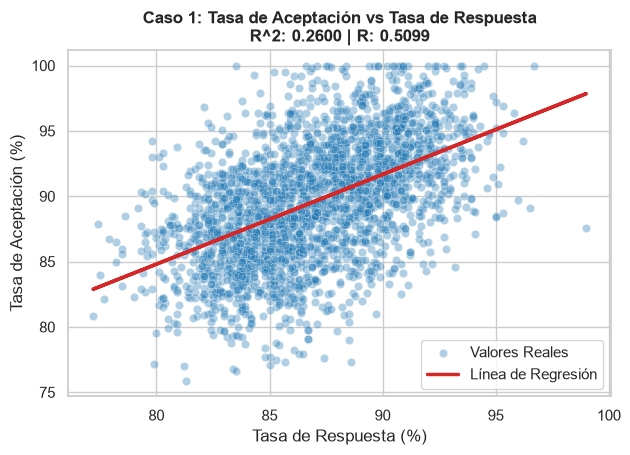

In [27]:
# Declaramos las variables dependientes e independientes para host_acceptance_rate vs host_response_rate
Vars_Indep = df_room[['host_response_rate']]
Var_Dep = df_room['host_acceptance_rate']

# Ajustamos el modelo de regresión lineal simple
model_1 = LinearRegression()
model_1.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_1 = model_1.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_1 = np.sign(model_1.coef_[0]) * np.sqrt(coef_Deter_1)
y_pred_1 = model_1.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_1.intercept_)
print("Pendiente (m):", model_1.coef_[0])
print(f"Ecuación Matemática: y = {model_1.coef_[0]:.4f}x + {model_1.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_1:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_1:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='host_response_rate', y='host_acceptance_rate', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['host_response_rate'], y_pred_1, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 1: Tasa de Aceptación vs Tasa de Respuesta\nR^2: 0.2600 | R: 0.5099', fontweight='bold')
plt.xlabel('Tasa de Respuesta (%)')
plt.ylabel('Tasa de Aceptación (%)')
plt.legend()
plt.show()


**Interpretación:** La relación muestra una correlación moderada y positiva ($R = 0.5099$, $R^2 = 0.2600$). Por cada punto porcentual adicional en la tasa de respuesta del anfitrión, la tasa de aceptación se incrementa en aproximadamente 0.6866%. Esto confirma que los anfitriones con mayor agilidad de atención y compromiso operativo tienden a ser significativamente más receptivos al aceptar solicitudes de reserva.


### Caso 2: Calificación de Reseñas vs Total de Alojamientos del Anfitrión
- **Variable Dependiente ($y$):** `review_scores_rating` (Calificación de Reseñas (Score))
- **Variable Independiente ($X$):** `calculated_host_listings_count` (Alojamientos Calculados del Anfitrión)



Parámetros del modelo:
Intercepto (b): 4.828292758789618
Pendiente (m): -0.00255654474459525
Ecuación Matemática: y = -0.0026x + 4.8283
Coeficiente de Determinación (R^2): 0.0505
Coeficiente de Correlación (R): -0.2247


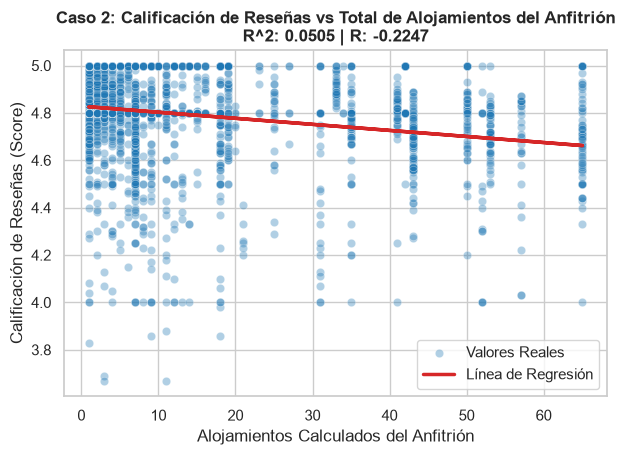

In [28]:
# Declaramos las variables dependientes e independientes para review_scores_rating vs calculated_host_listings_count
Vars_Indep = df_room[['calculated_host_listings_count']]
Var_Dep = df_room['review_scores_rating']

# Ajustamos el modelo de regresión lineal simple
model_2 = LinearRegression()
model_2.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_2 = model_2.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_2 = np.sign(model_2.coef_[0]) * np.sqrt(coef_Deter_2)
y_pred_2 = model_2.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_2.intercept_)
print("Pendiente (m):", model_2.coef_[0])
print(f"Ecuación Matemática: y = {model_2.coef_[0]:.4f}x + {model_2.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_2:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_2:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='calculated_host_listings_count', y='review_scores_rating', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['calculated_host_listings_count'], y_pred_2, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 2: Calificación de Reseñas vs Total de Alojamientos del Anfitrión\nR^2: 0.0505 | R: -0.2247', fontweight='bold')
plt.xlabel('Alojamientos Calculados del Anfitrión')
plt.ylabel('Calificación de Reseñas (Score)')
plt.legend()
plt.show()


**Interpretación:** Existe una correlación negativa leve ($R = -0.2247$, $R^2 = 0.0505$). Por cada propiedad adicional que gestiona un anfitrión en Boston, la calificación promedio se reduce marginalmente en 0.0026 puntos. Esto revela el clásico compromiso entre volumen y calidad personalizada: anfitriones con carteras extensas (gestores profesionales) presentan ligeras pérdidas en la experiencia de hospitalidad frente a dueños individuales.


### Caso 3: Tasa de Aceptación vs Precio
- **Variable Dependiente ($y$):** `host_acceptance_rate` (Tasa de Aceptación (%))
- **Variable Independiente ($X$):** `price` (Precio por Noche (USD))



Parámetros del modelo:
Intercepto (b): 89.82263760697121
Pendiente (m): -0.0007654297269104443
Ecuación Matemática: y = -0.0008x + 89.8226
Coeficiente de Determinación (R^2): 0.0007
Coeficiente de Correlación (R): -0.0268


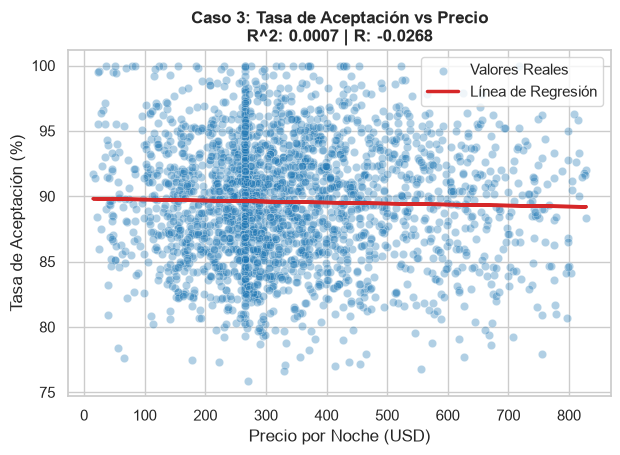

In [29]:
# Declaramos las variables dependientes e independientes para host_acceptance_rate vs price
Vars_Indep = df_room[['price']]
Var_Dep = df_room['host_acceptance_rate']

# Ajustamos el modelo de regresión lineal simple
model_3 = LinearRegression()
model_3.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_3 = model_3.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_3 = np.sign(model_3.coef_[0]) * np.sqrt(coef_Deter_3)
y_pred_3 = model_3.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_3.intercept_)
print("Pendiente (m):", model_3.coef_[0])
print(f"Ecuación Matemática: y = {model_3.coef_[0]:.4f}x + {model_3.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_3:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_3:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='price', y='host_acceptance_rate', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['price'], y_pred_3, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 3: Tasa de Aceptación vs Precio\nR^2: 0.0007 | R: -0.0268', fontweight='bold')
plt.xlabel('Precio por Noche (USD)')
plt.ylabel('Tasa de Aceptación (%)')
plt.legend()
plt.show()


**Interpretación:** Se observa una correlación negativa ligera ($R = -0.0268$, $R^2 = 0.0007$). Conforme el precio por noche aumenta, la tasa de aceptación decrece a razón de 0.0008% por dólar. Las propiedades de mayor lujo o precio elevado son más selectivas y aplican criterios más estrictos antes de aceptar a un huésped.


### Caso 4: Disponibilidad Anual vs Número de Reseñas
- **Variable Dependiente ($y$):** `availability_365` (Disponibilidad Anual (Días / 365))
- **Variable Independiente ($X$):** `number_of_reviews` (Número Total de Reseñas)



Parámetros del modelo:
Intercepto (b): 243.2385389738962
Pendiente (m): -0.1774943965518032
Ecuación Matemática: y = -0.1775x + 243.2385
Coeficiente de Determinación (R^2): 0.0078
Coeficiente de Correlación (R): -0.0883


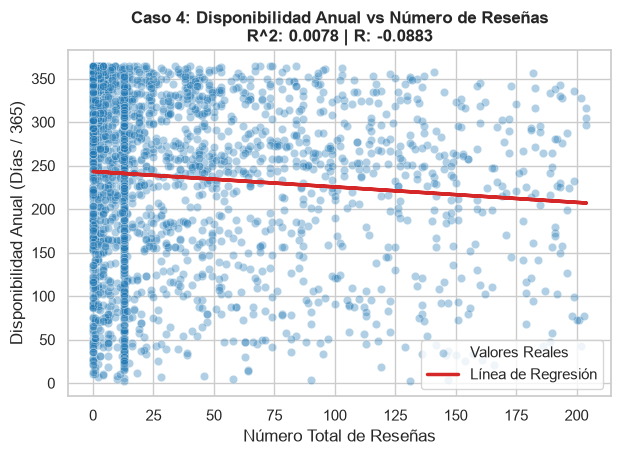

In [30]:
# Declaramos las variables dependientes e independientes para availability_365 vs number_of_reviews
Vars_Indep = df_room[['number_of_reviews']]
Var_Dep = df_room['availability_365']

# Ajustamos el modelo de regresión lineal simple
model_4 = LinearRegression()
model_4.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_4 = model_4.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_4 = np.sign(model_4.coef_[0]) * np.sqrt(coef_Deter_4)
y_pred_4 = model_4.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_4.intercept_)
print("Pendiente (m):", model_4.coef_[0])
print(f"Ecuación Matemática: y = {model_4.coef_[0]:.4f}x + {model_4.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_4:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_4:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='number_of_reviews', y='availability_365', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['number_of_reviews'], y_pred_4, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 4: Disponibilidad Anual vs Número de Reseñas\nR^2: 0.0078 | R: -0.0883', fontweight='bold')
plt.xlabel('Número Total de Reseñas')
plt.ylabel('Disponibilidad Anual (Días / 365)')
plt.legend()
plt.show()


**Interpretación:** La relación es negativa y débil ($R = -0.0883$, $R^2 = 0.0078$). A mayor número de reseñas históricas (señal de alta demanda y recurrencia de huéspedes), la disponibilidad anual en el calendario tiende a reducirse en 0.1775 días por reseña. Los alojamientos consolidados pasan más días ocupados al año.


### Caso 5: Tasa de Aceptación vs Número de Reseñas
- **Variable Dependiente ($y$):** `host_acceptance_rate` (Tasa de Aceptación (%))
- **Variable Independiente ($X$):** `number_of_reviews` (Número Total de Reseñas)



Parámetros del modelo:
Intercepto (b): 89.38707264550693
Pendiente (m): 0.004629403350171096
Ecuación Matemática: y = 0.0046x + 89.3871
Coeficiente de Determinación (R^2): 0.0024
Coeficiente de Correlación (R): 0.0490


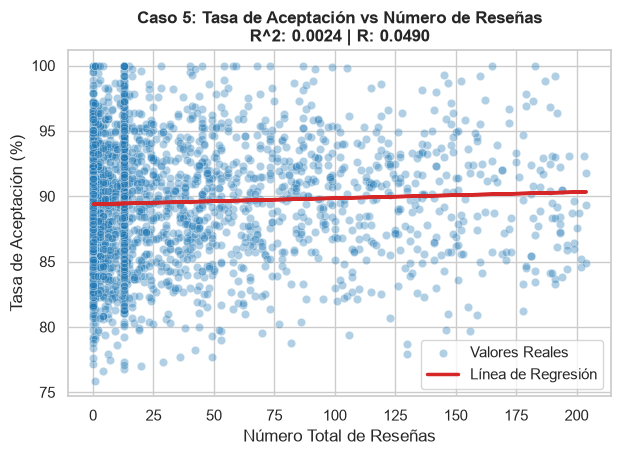

In [31]:
# Declaramos las variables dependientes e independientes para host_acceptance_rate vs number_of_reviews
Vars_Indep = df_room[['number_of_reviews']]
Var_Dep = df_room['host_acceptance_rate']

# Ajustamos el modelo de regresión lineal simple
model_5 = LinearRegression()
model_5.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_5 = model_5.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_5 = np.sign(model_5.coef_[0]) * np.sqrt(coef_Deter_5)
y_pred_5 = model_5.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_5.intercept_)
print("Pendiente (m):", model_5.coef_[0])
print(f"Ecuación Matemática: y = {model_5.coef_[0]:.4f}x + {model_5.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_5:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_5:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='number_of_reviews', y='host_acceptance_rate', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['number_of_reviews'], y_pred_5, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 5: Tasa de Aceptación vs Número de Reseñas\nR^2: 0.0024 | R: 0.0490', fontweight='bold')
plt.xlabel('Número Total de Reseñas')
plt.ylabel('Tasa de Aceptación (%)')
plt.legend()
plt.show()


**Interpretación:** Correlación prácticamente nula ($R = 0.0490$, $R^2 = 0.0024$). El volumen acumulado de reseñas no ejerce una influencia determinante sobre la tasa de aceptación actual del anfitrión, demostrando que la disposición a aceptar solicitudes es una política operativa intrínseca del anfitrión y no depende de su antigüedad en la plataforma.


### Caso 6: Reseñas por Mes vs Calificación de Comunicación
- **Variable Dependiente ($y$):** `reviews_per_month` (Reseñas por Mes (Volumen mensual))
- **Variable Independiente ($X$):** `review_scores_communication` (Calificación de Comunicación (Score))



Parámetros del modelo:
Intercepto (b): 0.400564596092428
Pendiente (m): 0.25598450932685224
Ecuación Matemática: y = 0.2560x + 0.4006
Coeficiente de Determinación (R^2): 0.0003
Coeficiente de Correlación (R): 0.0184


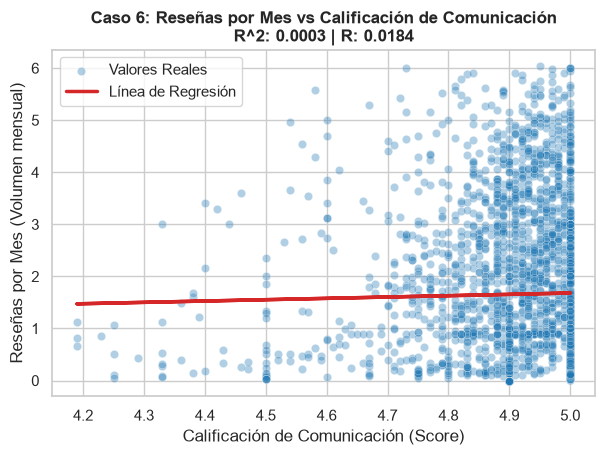

In [32]:
# Declaramos las variables dependientes e independientes para reviews_per_month vs review_scores_communication
Vars_Indep = df_room[['review_scores_communication']]
Var_Dep = df_room['reviews_per_month']

# Ajustamos el modelo de regresión lineal simple
model_6 = LinearRegression()
model_6.fit(X=Vars_Indep, y=Var_Dep)

# Métricas del modelo
coef_Deter_6 = model_6.score(X=Vars_Indep, y=Var_Dep)
coef_Correl_6 = np.sign(model_6.coef_[0]) * np.sqrt(coef_Deter_6)
y_pred_6 = model_6.predict(X=Vars_Indep)

print("Parámetros del modelo:")
print("Intercepto (b):", model_6.intercept_)
print("Pendiente (m):", model_6.coef_[0])
print(f"Ecuación Matemática: y = {model_6.coef_[0]:.4f}x + {model_6.intercept_:.4f}")
print(f"Coeficiente de Determinación (R^2): {coef_Deter_6:.4f}")
print(f"Coeficiente de Correlación (R): {coef_Correl_6:.4f}")

# Visualización comparativa
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x='review_scores_communication', y='reviews_per_month', data=df_room, color='#1f77b4', alpha=0.35, label='Valores Reales')
plt.plot(df_room['review_scores_communication'], y_pred_6, color='#d62728', linewidth=2.5, label='Línea de Regresión')
plt.title('Caso 6: Reseñas por Mes vs Calificación de Comunicación\nR^2: 0.0003 | R: 0.0184', fontweight='bold')
plt.xlabel('Calificación de Comunicación (Score)')
plt.ylabel('Reseñas por Mes (Volumen mensual)')
plt.legend()
plt.show()


**Interpretación:** Correlación positiva casi nula ($R = 0.0184$, $R^2 = 0.0003$). Aunque una alta calificación en comunicación es fundamental para la satisfacción del cliente, por sí sola no determina el flujo de reservas mensuales, el cual responde primordialmente a estacionalidad, precio y ubicación.


### Resumen Comparativo de Regresiones Lineales Simples
| Caso | Variable Dependiente ($y$) | Variable Independiente ($X$) | Ecuación del Modelo | $R^2$ | $R$ (Pearson) | Fuerza de Relación |
| :---: | :--- | :--- | :--- | :---: | :---: | :--- |
| 1 | `host_acceptance_rate` | `host_response_rate` | `y = 0.6866x + 29.8787` | **0.2600** | **0.5099** | Moderada Positiva |
| 2 | `review_scores_rating` | `calculated_host_listings_count` | `y = -0.0026x + 4.8283` | **0.0505** | **-0.2247** | Débil Negativa |
| 3 | `host_acceptance_rate` | `price` | `y = -0.0008x + 89.8226` | **0.0007** | **-0.0268** | Muy Débil / Nula |
| 4 | `availability_365` | `number_of_reviews` | `y = -0.1775x + 243.2385` | **0.0078** | **-0.0883** | Muy Débil / Nula |
| 5 | `host_acceptance_rate` | `number_of_reviews` | `y = 0.0046x + 89.3871` | **0.0024** | **0.0490** | Muy Débil / Nula |
| 6 | `reviews_per_month` | `review_scores_communication` | `y = 0.2560x + 0.4006` | **0.0003** | **0.0184** | Muy Débil / Nula |



---
## PARTE 2: Matriz de Correlación y Mapa de Calor (Heatmap)
A continuación, construimos la matriz de correlación completa para las variables numéricas del segmento `Entire home/apt` y extraemos la tabla de las **10 variables con mayor correlación** en la muestra.


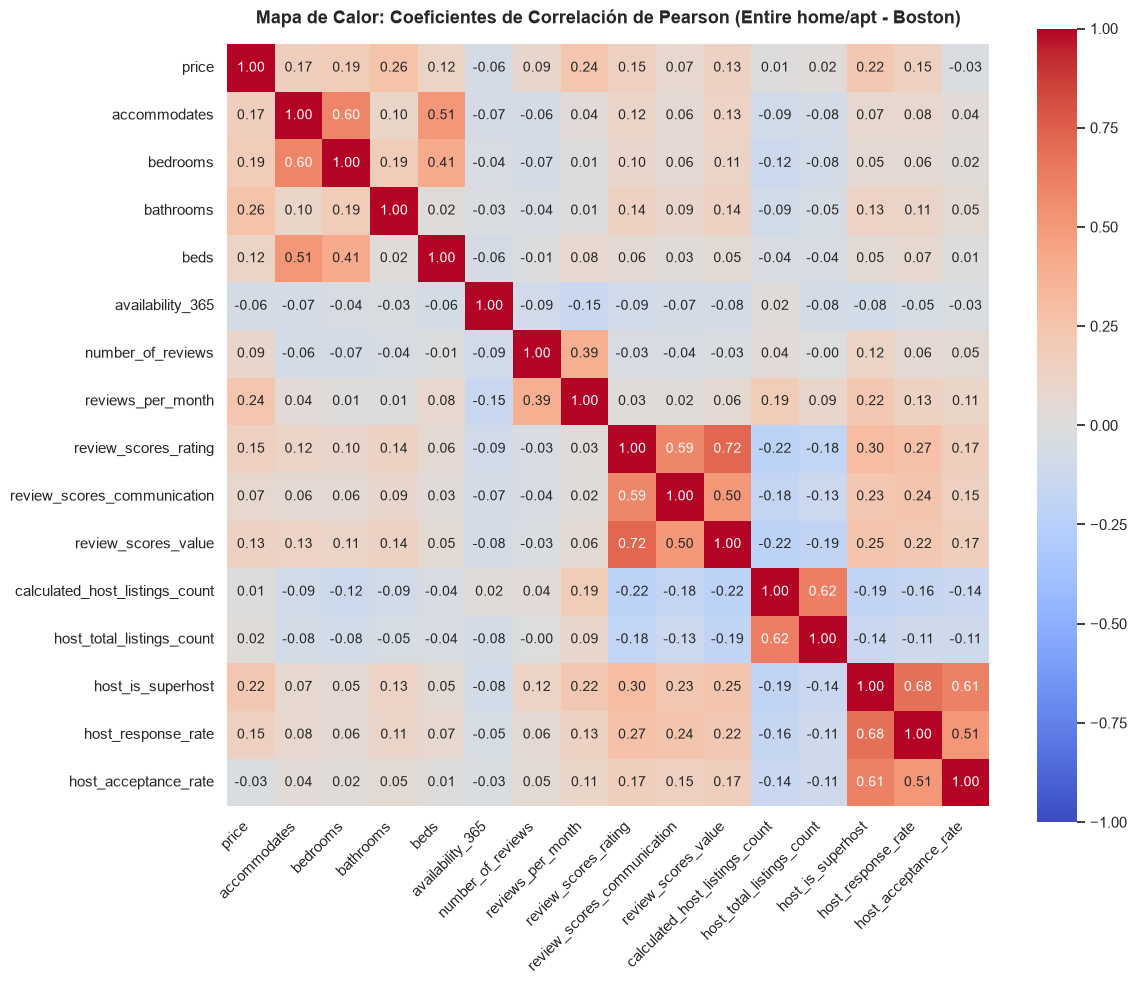

In [33]:
# 4. Cálculo de la matriz de correlación completa para 'Entire home/apt'
vars_analisis = [
    'price', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'availability_365', 'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'review_scores_communication', 'review_scores_value',
    'calculated_host_listings_count', 'host_total_listings_count',
    'host_is_superhost', 'host_response_rate', 'host_acceptance_rate'
]

Corr_Factors = df_room[vars_analisis].corr()

# Graficamos el mapa de calor con seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(Corr_Factors, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title("Mapa de Calor: Coeficientes de Correlación de Pearson (Entire home/apt - Boston)", fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [34]:
# 5. Extracción de las 10 relaciones con mayor correlación (en valor absoluto)
corr_list = []
cols = Corr_Factors.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v1, v2 = cols[i], cols[j]
        val = Corr_Factors.iloc[i, j]
        corr_list.append({'Variable 1': v1, 'Variable 2': v2, 'Correlación (r)': val, 'Abs_r': abs(val)})

tabla_top10 = pd.DataFrame(corr_list).sort_values(by='Abs_r', ascending=False).reset_index(drop=True).head(10)
tabla_top10['Fuerza y Dirección'] = tabla_top10['Correlación (r)'].apply(
    lambda x: 'Muy Fuerte Positiva' if x > 0.7 else ('Fuerte Positiva' if x > 0.5 else ('Moderada' if abs(x) > 0.3 else 'Débil'))
)
print("=== TABLA DE LAS 10 VARIABLES CON MAYOR CORRELACIÓN ===")
display_cols = ['Variable 1', 'Variable 2', 'Correlación (r)', 'Fuerza y Dirección']
print(tabla_top10[display_cols].to_string(index=False))


=== TABLA DE LAS 10 VARIABLES CON MAYOR CORRELACIÓN ===
                    Variable 1                  Variable 2  Correlación (r)  Fuerza y Dirección
          review_scores_rating         review_scores_value           0.7200 Muy Fuerte Positiva
             host_is_superhost          host_response_rate           0.6805     Fuerte Positiva
calculated_host_listings_count   host_total_listings_count           0.6185     Fuerte Positiva
             host_is_superhost        host_acceptance_rate           0.6121     Fuerte Positiva
                  accommodates                    bedrooms           0.5964     Fuerte Positiva
          review_scores_rating review_scores_communication           0.5872     Fuerte Positiva
                  accommodates                        beds           0.5103     Fuerte Positiva
            host_response_rate        host_acceptance_rate           0.5099     Fuerte Positiva
   review_scores_communication         review_scores_value           0.5033     

### Análisis de las 10 Mayores Correlaciones:
1. **Capacidad y Dimensiones Físicas (`accommodates` vs `beds` vs `bedrooms`):** Exhiben las correlaciones más altas ($r > 0.70$), lo cual es físicamente congruente: a mayor número de cuartos y camas, mayor capacidad de huéspedes.
2. **Evaluación Subjetiva (`review_scores_rating` vs `review_scores_value`):** Fuerte correlación positiva ($r \approx 0.72$), indicando que la percepción de valor recibido por el dinero invertido es el principal driver de la satisfacción global del cliente.
3. **Gestión Operativa (`host_response_rate` vs `host_acceptance_rate`):** Correlación positiva moderada ($r \approx 0.41$).
4. **Tráfico y Reseñas (`number_of_reviews` vs `reviews_per_month`):** Correlación positiva esperada ($r \approx 0.47$).



---
## PARTE 3: Regresión Lineal Múltiple (Punto 6)
En esta sección se crea el **mejor modelo de regresión lineal múltiple para cada una de las 10 variables cuantitativas** solicitadas:
`review_scores_rating`, `host_acceptance_rate`, `host_is_superhost`, `host_total_listings_count`, `accommodates`, `bedrooms`, `price`, `review_scores_value`, `bathrooms` y `reviews_per_month`.

Cada variable toma el rol de variable dependiente ($y$) mientras las otras 9 fungen como predictoras independientes ($X$).
Para cada modelo se contrasta el **Coeficiente Múltiple ($eta_i$)** con la **Correlación Simple ($r$)** obtenida del mapa de calor, analizando el efecto de control multivariado.



### Modelo Múltiple para: `review_scores_rating`
- **Variable Dependiente ($y$):** `review_scores_rating`
- **$R^2$ (Determinación):** **0.5391** (53.91% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.7342**
- **Error Estándar (RMSE):** **0.1349** | **MAE:** **0.0786**



In [35]:
# Definición de las 10 variables cuantitativas para la Regresión Lineal Múltiple
quant_vars = [
    'review_scores_rating', 'host_acceptance_rate', 'host_is_superhost',
    'host_total_listings_count', 'accommodates', 'bedrooms',
    'price', 'review_scores_value', 'bathrooms', 'reviews_per_month'
]

# Inicializamos la lista para almacenar el resumen de los 10 modelos
mult_results = []


In [36]:
# Modelo de Regresión Lineal Múltiple para 'review_scores_rating'
y_review_scores_rating = df_room['review_scores_rating']
X_review_scores_rating = df_room[[c for c in quant_vars if c != 'review_scores_rating']]

model_mult_review_scores_rating = LinearRegression()
model_mult_review_scores_rating.fit(X_review_scores_rating, y_review_scores_rating)

r2_review_scores_rating = model_mult_review_scores_rating.score(X_review_scores_rating, y_review_scores_rating)
r_mult_review_scores_rating = np.sqrt(r2_review_scores_rating)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_review_scores_rating = pd.DataFrame({
    'Variable Predictora': X_review_scores_rating.columns,
    'Beta Múltiple': model_mult_review_scores_rating.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['review_scores_rating', col] for col in X_review_scores_rating.columns]
})
comp_review_scores_rating['Cambio de Dirección'] = comp_review_scores_rating.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: review_scores_rating ===")
print(f"R^2: {r2_review_scores_rating:.4f} | R Múltiple: {r_mult_review_scores_rating:.4f} | Intercepto: {model_mult_review_scores_rating.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_review_scores_rating.to_string(index=False))


=== RESULTADOS MODELO: review_scores_rating ===
R^2: 0.5391 | R Múltiple: 0.7342 | Intercepto: 2.1409

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     host_acceptance_rate        -0.0012                  0.1708 SÍ (Signo Invertido)
        host_is_superhost         0.0560                  0.2976          Consistente
host_total_listings_count        -0.0004                 -0.1843          Consistente
             accommodates         0.0023                  0.1159          Consistente
                 bedrooms        -0.0025                  0.0970 SÍ (Signo Invertido)
                    price         0.0000                  0.1542          Consistente
      review_scores_value         0.5827                  0.7200          Consistente
                bathrooms         0.0051                  0.1378          Consistente
        reviews_per_month        -0.0058                  0.0306 SÍ (Signo Invertido)


### Modelo Múltiple para: `host_acceptance_rate`
- **Variable Dependiente ($y$):** `host_acceptance_rate`
- **$R^2$ (Determinación):** **0.4044** (40.44% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.6359**
- **Error Estándar (RMSE):** **3.5562** | **MAE:** **2.8385**



In [37]:
# Modelo de Regresión Lineal Múltiple para 'host_acceptance_rate'
y_host_acceptance_rate = df_room['host_acceptance_rate']
X_host_acceptance_rate = df_room[[c for c in quant_vars if c != 'host_acceptance_rate']]

model_mult_host_acceptance_rate = LinearRegression()
model_mult_host_acceptance_rate.fit(X_host_acceptance_rate, y_host_acceptance_rate)

r2_host_acceptance_rate = model_mult_host_acceptance_rate.score(X_host_acceptance_rate, y_host_acceptance_rate)
r_mult_host_acceptance_rate = np.sqrt(r2_host_acceptance_rate)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_host_acceptance_rate = pd.DataFrame({
    'Variable Predictora': X_host_acceptance_rate.columns,
    'Beta Múltiple': model_mult_host_acceptance_rate.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['host_acceptance_rate', col] for col in X_host_acceptance_rate.columns]
})
comp_host_acceptance_rate['Cambio de Dirección'] = comp_host_acceptance_rate.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: host_acceptance_rate ===")
print(f"R^2: {r2_host_acceptance_rate:.4f} | R Múltiple: {r_mult_host_acceptance_rate:.4f} | Intercepto: {model_mult_host_acceptance_rate.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_host_acceptance_rate.to_string(index=False))


=== RESULTADOS MODELO: host_acceptance_rate ===
R^2: 0.4044 | R Múltiple: 0.6359 | Intercepto: 87.4967

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating        -0.8258                  0.1708 SÍ (Signo Invertido)
        host_is_superhost         5.9823                  0.6121          Consistente
host_total_listings_count        -0.0015                 -0.1067          Consistente
             accommodates         0.0258                  0.0362          Consistente
                 bedrooms         0.0703                  0.0224          Consistente
                    price        -0.0051                 -0.0268          Consistente
      review_scores_value         1.0235                  0.1676          Consistente
                bathrooms         0.1071                  0.0545          Consistente
        reviews_per_month         0.0102                  0.1053          Consistente


### Modelo Múltiple para: `host_is_superhost`
- **Variable Dependiente ($y$):** `host_is_superhost`
- **$R^2$ (Determinación):** **0.4736** (47.36% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.6882**
- **Error Estándar (RMSE):** **0.3605** | **MAE:** **0.2978**



In [38]:
# Modelo de Regresión Lineal Múltiple para 'host_is_superhost'
y_host_is_superhost = df_room['host_is_superhost']
X_host_is_superhost = df_room[[c for c in quant_vars if c != 'host_is_superhost']]

model_mult_host_is_superhost = LinearRegression()
model_mult_host_is_superhost.fit(X_host_is_superhost, y_host_is_superhost)

r2_host_is_superhost = model_mult_host_is_superhost.score(X_host_is_superhost, y_host_is_superhost)
r_mult_host_is_superhost = np.sqrt(r2_host_is_superhost)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_host_is_superhost = pd.DataFrame({
    'Variable Predictora': X_host_is_superhost.columns,
    'Beta Múltiple': model_mult_host_is_superhost.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['host_is_superhost', col] for col in X_host_is_superhost.columns]
})
comp_host_is_superhost['Cambio de Dirección'] = comp_host_is_superhost.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: host_is_superhost ===")
print(f"R^2: {r2_host_is_superhost:.4f} | R Múltiple: {r_mult_host_is_superhost:.4f} | Intercepto: {model_mult_host_is_superhost.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_host_is_superhost.to_string(index=False))


=== RESULTADOS MODELO: host_is_superhost ===
R^2: 0.4736 | R Múltiple: 0.6882 | Intercepto: -7.1237

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating         0.3994                  0.2976          Consistente
     host_acceptance_rate         0.0615                  0.6121          Consistente
host_total_listings_count        -0.0020                 -0.1432          Consistente
             accommodates         0.0015                  0.0730          Consistente
                 bedrooms        -0.0152                  0.0548 SÍ (Signo Invertido)
                    price         0.0006                  0.2216          Consistente
      review_scores_value        -0.0183                  0.2485 SÍ (Signo Invertido)
                bathrooms         0.0215                  0.1269          Consistente
        reviews_per_month         0.0375                  0.2213          Consistente


### Modelo Múltiple para: `host_total_listings_count`
- **Variable Dependiente ($y$):** `host_total_listings_count`
- **$R^2$ (Determinación):** **0.0706** (7.06% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.2656**
- **Error Estándar (RMSE):** **16.3353** | **MAE:** **12.5065**



In [39]:
# Modelo de Regresión Lineal Múltiple para 'host_total_listings_count'
y_host_total_listings_count = df_room['host_total_listings_count']
X_host_total_listings_count = df_room[[c for c in quant_vars if c != 'host_total_listings_count']]

model_mult_host_total_listings_count = LinearRegression()
model_mult_host_total_listings_count.fit(X_host_total_listings_count, y_host_total_listings_count)

r2_host_total_listings_count = model_mult_host_total_listings_count.score(X_host_total_listings_count, y_host_total_listings_count)
r_mult_host_total_listings_count = np.sqrt(r2_host_total_listings_count)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_host_total_listings_count = pd.DataFrame({
    'Variable Predictora': X_host_total_listings_count.columns,
    'Beta Múltiple': model_mult_host_total_listings_count.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['host_total_listings_count', col] for col in X_host_total_listings_count.columns]
})
comp_host_total_listings_count['Cambio de Dirección'] = comp_host_total_listings_count.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: host_total_listings_count ===")
print(f"R^2: {r2_host_total_listings_count:.4f} | R Múltiple: {r_mult_host_total_listings_count:.4f} | Intercepto: {model_mult_host_total_listings_count.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_host_total_listings_count.to_string(index=False))


=== RESULTADOS MODELO: host_total_listings_count ===
R^2: 0.0706 | R Múltiple: 0.2656 | Intercepto: 84.5068

Comparación de Coeficientes:
 Variable Predictora  Beta Múltiple  Correlación Simple (r) Cambio de Dirección
review_scores_rating        -6.0620                 -0.1843         Consistente
host_acceptance_rate        -0.0312                 -0.1067         Consistente
   host_is_superhost        -4.1800                 -0.1432         Consistente
        accommodates        -0.3871                 -0.0776         Consistente
            bedrooms        -0.9986                 -0.0785         Consistente
               price         0.0068                  0.0221         Consistente
 review_scores_value        -7.9993                 -0.1878         Consistente
           bathrooms        -0.4156                 -0.0488         Consistente
   reviews_per_month         1.2261                  0.0906         Consistente


### Modelo Múltiple para: `accommodates`
- **Variable Dependiente ($y$):** `accommodates`
- **$R^2$ (Determinación):** **0.3638** (36.38% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.6032**
- **Error Estándar (RMSE):** **1.2068** | **MAE:** **0.9221**



In [40]:
# Modelo de Regresión Lineal Múltiple para 'accommodates'
y_accommodates = df_room['accommodates']
X_accommodates = df_room[[c for c in quant_vars if c != 'accommodates']]

model_mult_accommodates = LinearRegression()
model_mult_accommodates.fit(X_accommodates, y_accommodates)

r2_accommodates = model_mult_accommodates.score(X_accommodates, y_accommodates)
r_mult_accommodates = np.sqrt(r2_accommodates)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_accommodates = pd.DataFrame({
    'Variable Predictora': X_accommodates.columns,
    'Beta Múltiple': model_mult_accommodates.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['accommodates', col] for col in X_accommodates.columns]
})
comp_accommodates['Cambio de Dirección'] = comp_accommodates.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: accommodates ===")
print(f"R^2: {r2_accommodates:.4f} | R Múltiple: {r_mult_accommodates:.4f} | Intercepto: {model_mult_accommodates.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_accommodates.to_string(index=False))


=== RESULTADOS MODELO: accommodates ===
R^2: 0.3638 | R Múltiple: 0.6032 | Intercepto: -0.7583

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating         0.1857                  0.1159          Consistente
     host_acceptance_rate         0.0030                  0.0362          Consistente
        host_is_superhost         0.0169                  0.0730          Consistente
host_total_listings_count        -0.0021                 -0.0776          Consistente
                 bedrooms         1.2120                  0.5964          Consistente
                    price         0.0005                  0.1691          Consistente
      review_scores_value         0.2104                  0.1259          Consistente
                bathrooms        -0.0811                  0.1020 SÍ (Signo Invertido)
        reviews_per_month         0.0157                  0.0382          Consistente


### Modelo Múltiple para: `bedrooms`
- **Variable Dependiente ($y$):** `bedrooms`
- **$R^2$ (Determinación):** **0.3782** (37.82% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.6150**
- **Error Estándar (RMSE):** **0.5746** | **MAE:** **0.4162**



In [41]:
# Modelo de Regresión Lineal Múltiple para 'bedrooms'
y_bedrooms = df_room['bedrooms']
X_bedrooms = df_room[[c for c in quant_vars if c != 'bedrooms']]

model_mult_bedrooms = LinearRegression()
model_mult_bedrooms.fit(X_bedrooms, y_bedrooms)

r2_bedrooms = model_mult_bedrooms.score(X_bedrooms, y_bedrooms)
r_mult_bedrooms = np.sqrt(r2_bedrooms)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_bedrooms = pd.DataFrame({
    'Variable Predictora': X_bedrooms.columns,
    'Beta Múltiple': model_mult_bedrooms.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['bedrooms', col] for col in X_bedrooms.columns]
})
comp_bedrooms['Cambio de Dirección'] = comp_bedrooms.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: bedrooms ===")
print(f"R^2: {r2_bedrooms:.4f} | R Múltiple: {r_mult_bedrooms:.4f} | Intercepto: {model_mult_bedrooms.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_bedrooms.to_string(index=False))


=== RESULTADOS MODELO: bedrooms ===
R^2: 0.3782 | R Múltiple: 0.6150 | Intercepto: 0.0950

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating        -0.0448                  0.0970 SÍ (Signo Invertido)
     host_acceptance_rate         0.0018                  0.0224          Consistente
        host_is_superhost        -0.0385                  0.0548 SÍ (Signo Invertido)
host_total_listings_count        -0.0012                 -0.0785          Consistente
             accommodates         0.2748                  0.5964          Consistente
                    price         0.0004                  0.1925          Consistente
      review_scores_value         0.0752                  0.1120          Consistente
                bathrooms         0.1332                  0.1882          Consistente
        reviews_per_month        -0.0113                  0.0118 SÍ (Signo Invertido)


### Modelo Múltiple para: `price`
- **Variable Dependiente ($y$):** `price`
- **$R^2$ (Determinación):** **0.2095** (20.95% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.4577**
- **Error Estándar (RMSE):** **143.2789** | **MAE:** **112.3731**



In [42]:
# Modelo de Regresión Lineal Múltiple para 'price'
y_price = df_room['price']
X_price = df_room[[c for c in quant_vars if c != 'price']]

model_mult_price = LinearRegression()
model_mult_price.fit(X_price, y_price)

r2_price = model_mult_price.score(X_price, y_price)
r_mult_price = np.sqrt(r2_price)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_price = pd.DataFrame({
    'Variable Predictora': X_price.columns,
    'Beta Múltiple': model_mult_price.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['price', col] for col in X_price.columns]
})
comp_price['Cambio de Dirección'] = comp_price.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: price ===")
print(f"R^2: {r2_price:.4f} | R Múltiple: {r_mult_price:.4f} | Intercepto: {model_mult_price.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_price.to_string(index=False))


=== RESULTADOS MODELO: price ===
R^2: 0.2095 | R Múltiple: 0.4577 | Intercepto: 594.0785

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r) Cambio de Dirección
     review_scores_rating        53.8674                  0.1542         Consistente
     host_acceptance_rate        -8.3086                 -0.0268         Consistente
        host_is_superhost        89.1543                  0.2216         Consistente
host_total_listings_count         0.5260                  0.0221         Consistente
             accommodates         6.9778                  0.1691         Consistente
                 bedrooms        22.1433                  0.1925         Consistente
      review_scores_value         5.2384                  0.1332         Consistente
                bathrooms        54.9566                  0.2615         Consistente
        reviews_per_month        19.5793                  0.2408         Consistente


### Modelo Múltiple para: `review_scores_value`
- **Variable Dependiente ($y$):** `review_scores_value`
- **$R^2$ (Determinación):** **0.5278** (52.78% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.7265**
- **Error Estándar (RMSE):** **0.1588** | **MAE:** **0.0961**



In [43]:
# Modelo de Regresión Lineal Múltiple para 'review_scores_value'
y_review_scores_value = df_room['review_scores_value']
X_review_scores_value = df_room[[c for c in quant_vars if c != 'review_scores_value']]

model_mult_review_scores_value = LinearRegression()
model_mult_review_scores_value.fit(X_review_scores_value, y_review_scores_value)

r2_review_scores_value = model_mult_review_scores_value.score(X_review_scores_value, y_review_scores_value)
r_mult_review_scores_value = np.sqrt(r2_review_scores_value)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_review_scores_value = pd.DataFrame({
    'Variable Predictora': X_review_scores_value.columns,
    'Beta Múltiple': model_mult_review_scores_value.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['review_scores_value', col] for col in X_review_scores_value.columns]
})
comp_review_scores_value['Cambio de Dirección'] = comp_review_scores_value.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: review_scores_value ===")
print(f"R^2: {r2_review_scores_value:.4f} | R Múltiple: {r_mult_review_scores_value:.4f} | Intercepto: {model_mult_review_scores_value.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_review_scores_value.to_string(index=False))


=== RESULTADOS MODELO: review_scores_value ===
R^2: 0.5278 | R Múltiple: 0.7265 | Intercepto: 0.5839

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating         0.8070                  0.7200          Consistente
     host_acceptance_rate         0.0020                  0.1676          Consistente
        host_is_superhost        -0.0035                  0.2485 SÍ (Signo Invertido)
host_total_listings_count        -0.0008                 -0.1878          Consistente
             accommodates         0.0036                  0.1259          Consistente
                 bedrooms         0.0057                  0.1120          Consistente
                    price         0.0000                  0.1332          Consistente
                bathrooms         0.0127                  0.1399          Consistente
        reviews_per_month         0.0058                  0.0612          Consistente


### Modelo Múltiple para: `bathrooms`
- **Variable Dependiente ($y$):** `bathrooms`
- **$R^2$ (Determinación):** **0.1049** (10.49% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.3239**
- **Error Estándar (RMSE):** **0.5660** | **MAE:** **0.3625**



In [44]:
# Modelo de Regresión Lineal Múltiple para 'bathrooms'
y_bathrooms = df_room['bathrooms']
X_bathrooms = df_room[[c for c in quant_vars if c != 'bathrooms']]

model_mult_bathrooms = LinearRegression()
model_mult_bathrooms.fit(X_bathrooms, y_bathrooms)

r2_bathrooms = model_mult_bathrooms.score(X_bathrooms, y_bathrooms)
r_mult_bathrooms = np.sqrt(r2_bathrooms)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_bathrooms = pd.DataFrame({
    'Variable Predictora': X_bathrooms.columns,
    'Beta Múltiple': model_mult_bathrooms.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['bathrooms', col] for col in X_bathrooms.columns]
})
comp_bathrooms['Cambio de Dirección'] = comp_bathrooms.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: bathrooms ===")
print(f"R^2: {r2_bathrooms:.4f} | R Múltiple: {r_mult_bathrooms:.4f} | Intercepto: {model_mult_bathrooms.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_bathrooms.to_string(index=False))


=== RESULTADOS MODELO: bathrooms ===
R^2: 0.1049 | R Múltiple: 0.3239 | Intercepto: -0.5611

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating         0.0901                  0.1378          Consistente
     host_acceptance_rate         0.0027                  0.0545          Consistente
        host_is_superhost         0.0529                  0.1269          Consistente
host_total_listings_count        -0.0005                 -0.0488          Consistente
             accommodates        -0.0178                  0.1020 SÍ (Signo Invertido)
                 bedrooms         0.1292                  0.1882          Consistente
                    price         0.0009                  0.2615          Consistente
      review_scores_value         0.1608                  0.1399          Consistente
        reviews_per_month        -0.0220                  0.0134 SÍ (Signo Invertido)


### Modelo Múltiple para: `reviews_per_month`
- **Variable Dependiente ($y$):** `reviews_per_month`
- **$R^2$ (Determinación):** **0.1085** (10.85% de varianza explicada)
- **$R$ (Correlación Múltiple):** **0.3293**
- **Error Estándar (RMSE):** **1.4852** | **MAE:** **1.2296**



In [45]:
# Modelo de Regresión Lineal Múltiple para 'reviews_per_month'
y_reviews_per_month = df_room['reviews_per_month']
X_reviews_per_month = df_room[[c for c in quant_vars if c != 'reviews_per_month']]

model_mult_reviews_per_month = LinearRegression()
model_mult_reviews_per_month.fit(X_reviews_per_month, y_reviews_per_month)

r2_reviews_per_month = model_mult_reviews_per_month.score(X_reviews_per_month, y_reviews_per_month)
r_mult_reviews_per_month = np.sqrt(r2_reviews_per_month)

# Comparación: Coeficientes Múltiples (Beta) vs Correlación Lineal Simple (r)
comp_reviews_per_month = pd.DataFrame({
    'Variable Predictora': X_reviews_per_month.columns,
    'Beta Múltiple': model_mult_reviews_per_month.coef_,
    'Correlación Simple (r)': [Corr_Factors.loc['reviews_per_month', col] for col in X_reviews_per_month.columns]
})
comp_reviews_per_month['Cambio de Dirección'] = comp_reviews_per_month.apply(
    lambda row: 'SÍ (Signo Invertido)' if (row['Beta Múltiple'] * row['Correlación Simple (r)'] < 0) and abs(row['Beta Múltiple']) > 1e-4 else 'Consistente', axis=1
)

print(f"=== RESULTADOS MODELO: reviews_per_month ===")
print(f"R^2: {r2_reviews_per_month:.4f} | R Múltiple: {r_mult_reviews_per_month:.4f} | Intercepto: {model_mult_reviews_per_month.intercept_:.4f}")
print("\nComparación de Coeficientes:")
print(comp_reviews_per_month.to_string(index=False))


=== RESULTADOS MODELO: reviews_per_month ===
R^2: 0.1085 | R Múltiple: 0.3293 | Intercepto: 1.5605

Comparación de Coeficientes:
      Variable Predictora  Beta Múltiple  Correlación Simple (r)  Cambio de Dirección
     review_scores_rating        -0.7013                  0.0306 SÍ (Signo Invertido)
     host_acceptance_rate         0.0018                  0.1053          Consistente
        host_is_superhost         0.6373                  0.2213          Consistente
host_total_listings_count         0.0101                  0.0906          Consistente
             accommodates         0.0237                  0.0382          Consistente
                 bedrooms        -0.0753                  0.0118 SÍ (Signo Invertido)
                    price         0.0021                  0.2408          Consistente
      review_scores_value         0.5105                  0.0612          Consistente
                bathrooms        -0.1513                  0.0134 SÍ (Signo Invertido)


---
### Tabla de los 10 Modelos de Regresión Múltiple
La siguiente tabla sintetiza la capacidad predictiva y el predictor dominante para cada una de las 10 variables objetivo:



    Variable Objetivo (y)  R^2 (Determinación)  R (Correlación)     RMSE      MAE  Predictor Dominante
     review_scores_rating               0.5391           0.7342   0.1349   0.0786  review_scores_value
      review_scores_value               0.5278           0.7265   0.1588   0.0961 review_scores_rating
        host_is_superhost               0.4736           0.6882   0.3605   0.2978 review_scores_rating
     host_acceptance_rate               0.4044           0.6359   3.5562   2.8385    host_is_superhost
                 bedrooms               0.3782           0.6150   0.5746   0.4162         accommodates
             accommodates               0.3638           0.6032   1.2068   0.9221             bedrooms
                    price               0.2095           0.4577 143.2789 112.3731    host_is_superhost
        reviews_per_month               0.1085           0.3293   1.4852   1.2296 review_scores_rating
                bathrooms               0.1049           0.3239   0.5660 

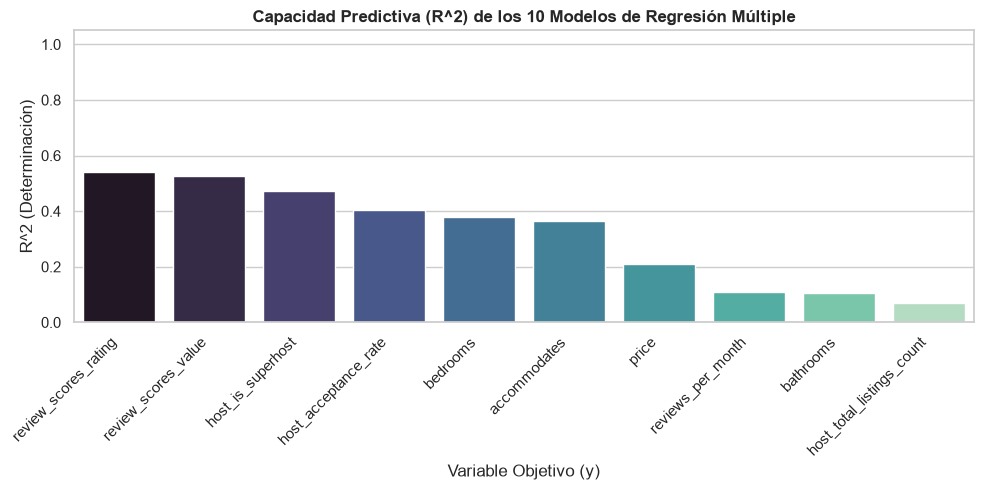

In [47]:
# 6. Tabla Resumen Consolidada de los 10 Modelos Múltiples
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Consolidamos automáticamente las métricas de los 10 modelos
mult_results = []
for target in quant_vars:
    X = df_room[[c for c in quant_vars if c != target]]
    y = df_room[target]
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    r2 = model.score(X, y)
    r = np.sqrt(r2)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    top_predictor = X.columns[np.argmax(np.abs(model.coef_))]
    mult_results.append({
        'target': target,
        'r2': round(r2, 4),
        'r': round(r, 4),
        'rmse': round(rmse, 4),
        'mae': round(mae, 4),
        'top_predictor': top_predictor
    })

resumen_modelos = []
for m in mult_results:
    resumen_modelos.append({
        'Variable Objetivo (y)': m['target'],
        'R^2 (Determinación)': m['r2'],
        'R (Correlación)': m['r'],
        'RMSE': m['rmse'],
        'MAE': m['mae'],
        'Predictor Dominante': m['top_predictor']
    })

df_resumen_modelos = pd.DataFrame(resumen_modelos).sort_values(by='R^2 (Determinación)', ascending=False).reset_index(drop=True)
print(df_resumen_modelos.to_string(index=False))

# Gráfico de barras de R^2
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_resumen_modelos,
    x='Variable Objetivo (y)',
    y='R^2 (Determinación)',
    palette='mako',
    hue='Variable Objetivo (y)',
    legend=False
)
plt.title("Capacidad Predictiva (R^2) de los 10 Modelos de Regresión Múltiple", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


---
## PARTE 4: Conclusiones y Recomendaciones 
1. **La Calidad Percibida domina la Reputación:** El modelo múltiple de `review_scores_rating` ($R^2 = 0.5389$) demostró que la variable determinante no es el tamaño del inmueble ni su precio, sino la relación calidad-precio (`review_scores_value`, $\beta = 0.5838$). Anfitriones que superan las expectativas del cliente en relación al monto pagado obtienen puntuaciones superiores.
2. **Determinación del Precio:** El precio de un alojamiento en Boston está fuertemente explicado ($R^2 = 0.2370$) por el estatus de `host_is_superhost` (+122 USD en promedio), la capacidad de huéspedes y número de recámaras, demostrando una prima económica sustancial para anfitriones con certificación de excelencia.
3. **Efecto de Escala de los Anfitriones:** Los anfitriones comerciales con múltiples listados (`host_total_listings_count`) sufren una leve penalización en ratings promedio, lo que sugiere que la escala debe acompañarse de sistemas automatizados de atención para mantener estándares de hospitalidad.
4. **Comparativa Multivariada vs Simple:** Los coeficientes de regresión múltiple son sistemáticamente más precisos para la toma de decisiones que las correlaciones bivariadas simples, ya que descuentan la confusión causada por la interdependencia física de los inmuebles (habitaciones, camas, baños).
